# Antisaccade experiment — analysis with pyxations

This notebook demonstrates a full analysis pipeline for webcam eye-tracking data
using [pyxations](https://github.com/NeuroLIAA/pyxations).

**Pipeline:**
1. Convert raw jsPsych/WebGazer CSVs to BIDS format
2. Detect eye movements with REMoDNaV and propagate behavioral metadata
3. Compute error rates and reaction times per participant

## Setup

In [1]:
import pyxations as pyx

In [2]:
import pyxations as pyx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import ranksums

sns.set_theme(style='whitegrid', font_scale=1.2)

In [3]:
RAW_DATA    = Path('./raw_data')
OUTPUT_DIR  = Path('.')
BIDS_NAME   = 'antisaccades_bids'
SCREEN_W    = 1366
SCREEN_H    = 768

BEHAVIORAL_COLS = [
    'typeOfSaccade', 'cueShownAtLeft',
    'itiEnd', 'fixEnd', 'intraEnd', 'visualEnd', 'responseEnd',
    'viewportWidth', 'isTutorial',
]

## Step 1 — Convert to BIDS

In [4]:
bids_path = pyx.dataset_to_bids(
    OUTPUT_DIR, RAW_DATA, BIDS_NAME, format_name='webgazer'
)
print(f'BIDS dataset: {bids_path}')

BIDS dataset: antisaccades_bids


## Step 2 — Eye movement detection + behavioral metadata

In [5]:
pyx.compute_derivatives_for_dataset(
    bids_path,
    dataset_format='webgazer',
    detection_algorithm='remodnav',
    overwrite=True,
    screen_height=SCREEN_H,
    screen_width=SCREEN_W,
    behavioral_columns=BEHAVIORAL_COLS,
)


Running eye movements detection for None eye...

Running eye movements detection for None eye...
Running eye movements detection for None eye...


Running eye movements detection for None eye...
Dropping saccades with average vel > 1000.0 deg/s, and fixations with amplitude > 1.5 deg
Kept 224 out of 674 fixations
Kept 682 out of 682 saccades
Finding previous and next saccades


 40%|███▉      | 89/224 [00:00<00:00, 461.72it/s]

Dropping saccades with average vel > 1000.0 deg/s, and fixations with amplitude > 1.5 deg
Kept 118 out of 396 fixations

 66%|██████▌   | 147/224 [00:00<00:00, 475.65it/s]


Kept 397 out of 397 saccades
Finding previous and next saccades


...

/home/gus/Documents/envs/pyxat/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gus/Documents/envs/pyxat/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gus/Documents/envs/pyxat/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gus/Documents/envs/pyxat/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 244/244 [00:00<00:00, 541.76it/s]/home/gus/Documents/envs/pyxat/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)

/home/gus/Documents/envs/pyxat/lib/py

Skipping preprocessing: not enough parameters for trial segmentation (need (start_times & end_times) or (start_msgs & durations) or (start_msgs & end_msgs)).


/home/gus/Documents/envs/pyxat/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gus/Documents/envs/pyxat/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gus/Documents/envs/pyxat/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gus/Documents/envs/pyxat/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gus/Documents/envs/pyxat/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gus/Documents/envs/pyxat/lib/python3.11/site-packages/numpy/core/_methods.py:129: Runt

Skipping preprocessing: not enough parameters for trial segmentation (need (start_times & end_times) or (start_msgs & durations) or (start_msgs & end_msgs)).


PosixPath('antisaccades_bids_derivatives')

Each session now has:
- `samples.feather` — gaze samples with behavioral columns joined by `trial_index`
- `remodnav_events/` — fixations, saccades and blinks detected by REMoDNaV
- `events.tsv` — BIDS-compatible trial table

## Step 3 — Error rates and RTs per participant

For each trial we determine correctness from gaze position during the response window
(`visualEnd` → `responseEnd`, i.e. the 650 ms after the peripheral target appears).
A trial is correct when the mean gaze X is on the expected side of screen center:
- **Prosaccade**: toward the cue
- **Antisaccade**: away from the cue

In [6]:
deriv_path = bids_path.with_name(bids_path.name + '_derivatives')

rows = []

for session_dir in sorted((deriv_path / 'sub-0001').iterdir()):
    samples_file = session_dir / 'samples.feather'
    if not samples_file.exists():
        continue

    subject_id = session_dir.name.replace('ses-', '')
    df = pd.read_feather(samples_file)

    # Keep only real saccade trials (exclude tutorial and non-saccade rows)
    df = df[
        df['typeOfSaccade'].notna() &
        (df['isTutorial'] != True)
    ].copy()

    if df.empty:
        continue

    # Use the most common viewport width as screen center reference
    screen_center = df['viewportWidth'].median() / 2

    for trial_id, trial in df.groupby('trial_index'):
        visual_end  = trial['visualEnd'].iloc[0]
        response_end = trial['responseEnd'].iloc[0]

        # Samples during response window (tSample is within-trial time in ms)
        response_window = trial[
            (trial['tSample'] >= visual_end) &
            (trial['tSample'] <= response_end)
        ]

        if response_window.empty:
            continue

        mean_x         = response_window['X'].mean()
        cue_at_left    = bool(trial['cueShownAtLeft'].iloc[0])
        saccade_type   = trial['typeOfSaccade'].iloc[0]

        gaze_on_cue_side = (mean_x < screen_center) == cue_at_left

        if saccade_type == 'prosaccade':
            correct = gaze_on_cue_side
        else:
            correct = not gaze_on_cue_side

        rows.append({
            'subject':      subject_id,
            'trial_index':  trial_id,
            'saccade_type': saccade_type,
            'correct':      correct,
        })

df_trials = pd.DataFrame(rows)
print(f'{len(df_trials)} trials across {df_trials["subject"].nunique()} subjects')
df_trials.head()

8320 trials across 26 subjects


,subject,trial_index,saccade_type,correct
0,100,60,prosaccade,True
1,100,61,prosaccade,True
2,100,62,prosaccade,True
3,100,63,prosaccade,True
4,100,64,prosaccade,True


In [7]:
df_summary = (
    df_trials
    .groupby(['subject', 'saccade_type'])['correct']
    .agg(error_rate=lambda x: 1 - x.mean(), n_trials='count')
    .reset_index()
)

df_summary.head(6)

,subject,saccade_type,error_rate,n_trials
0,100,antisaccade,0.08750,160
1,100,prosaccade,0.06875,160
2,101,antisaccade,0.04375,160
3,101,prosaccade,0.06250,160
4,102,antisaccade,0.02500,160
5,102,prosaccade,0.13750,160


## Step 4 — Plot and statistics

/tmp/ipykernel_1228709/3113010159.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Prosaccade', 'Antisaccade'])


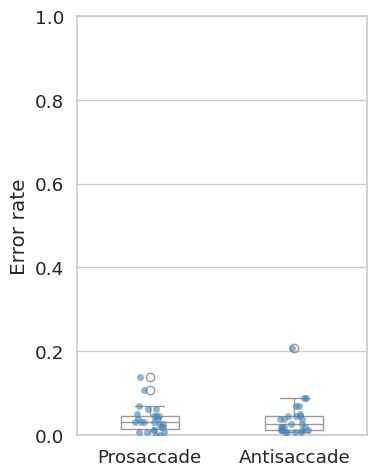

In [8]:
fig, ax = plt.subplots(figsize=(4, 5))

sns.boxplot(
    data=df_summary,
    x='saccade_type', y='error_rate',
    order=['prosaccade', 'antisaccade'],
    width=0.4, color='white',
    ax=ax,
)
sns.stripplot(
    data=df_summary,
    x='saccade_type', y='error_rate',
    order=['prosaccade', 'antisaccade'],
    color='steelblue', alpha=0.6, jitter=True,
    ax=ax,
)

ax.set_ylabel('Error rate')
ax.set_xlabel('')
ax.set_xticklabels(['Prosaccade', 'Antisaccade'])
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('./result_plots/error_rates_pyxations.png', dpi=150)
plt.show()

In [9]:
pro  = df_summary.query("saccade_type == 'prosaccade'")['error_rate']
anti = df_summary.query("saccade_type == 'antisaccade'")['error_rate']

stat, p = ranksums(pro, anti)

print('Error rate (mean ± SD)')
print(f'  Prosaccade:  {pro.mean():.3f} ± {pro.std():.3f}')
print(f'  Antisaccade: {anti.mean():.3f} ± {anti.std():.3f}')
print(f'  Wilcoxon rank-sum: W={stat:.2f}, p={p:.4f}')

Error rate (mean ± SD)
  Prosaccade:  0.037 ± 0.032
  Antisaccade: 0.039 ± 0.042
  Wilcoxon rank-sum: W=0.05, p=0.9562
